In [52]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
        

/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv


In [53]:
import pandas as pd

df = pd.read_csv(
    "/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv"
)

print(df.shape)
df.head()

(2640, 12)


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [54]:
print(df.shape)
print(df.columns)
print(df.info())

(2640, 12)
Index(['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries',
       'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'CO2_Saved_tons', 'Source_Type', 'Charging_Stations'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-nul

In [55]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


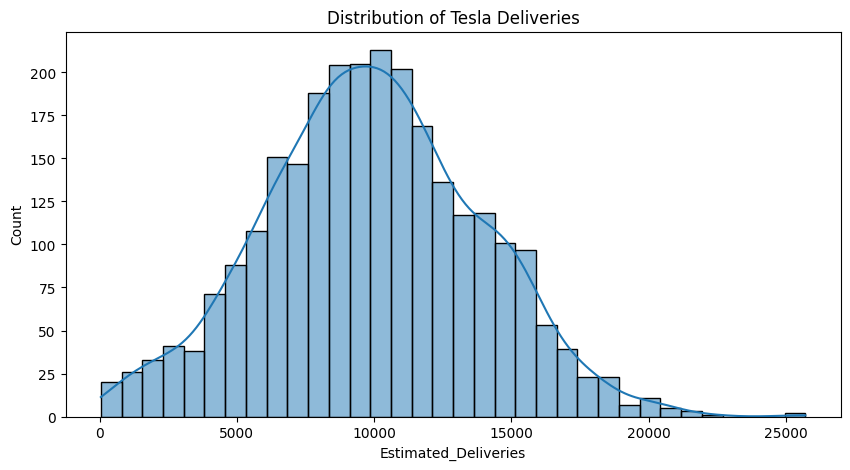

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.histplot(df["Estimated_Deliveries"], kde=True)

plt.title("Distribution of Tesla Deliveries")
plt.show()

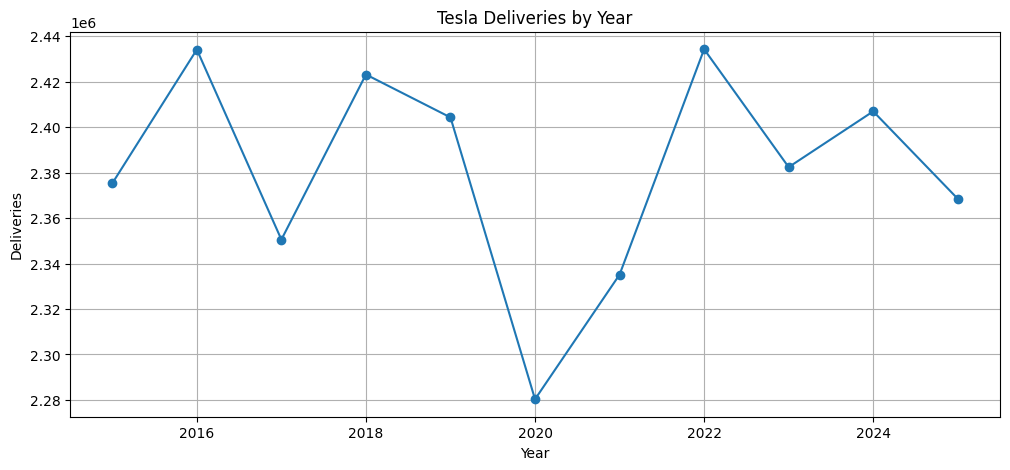

In [57]:
yearly_sales = df.groupby("Year")["Estimated_Deliveries"].sum()

plt.figure(figsize=(12,5))

yearly_sales.plot(marker="o")

plt.title("Tesla Deliveries by Year")
plt.ylabel("Deliveries")

plt.grid(True)

plt.show()

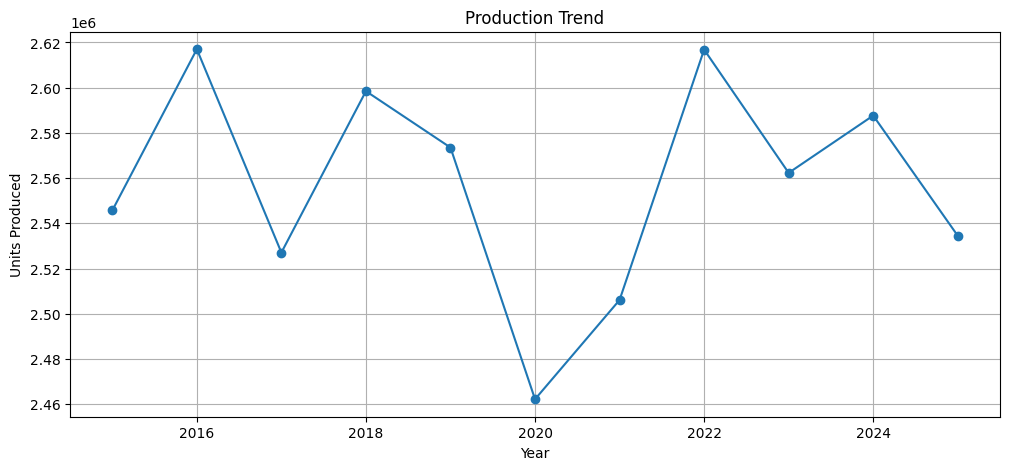

In [58]:
production = df.groupby("Year")["Production_Units"].sum()

plt.figure(figsize=(12,5))

production.plot(marker="o")

plt.title("Production Trend")
plt.ylabel("Units Produced")

plt.grid(True)

plt.show()

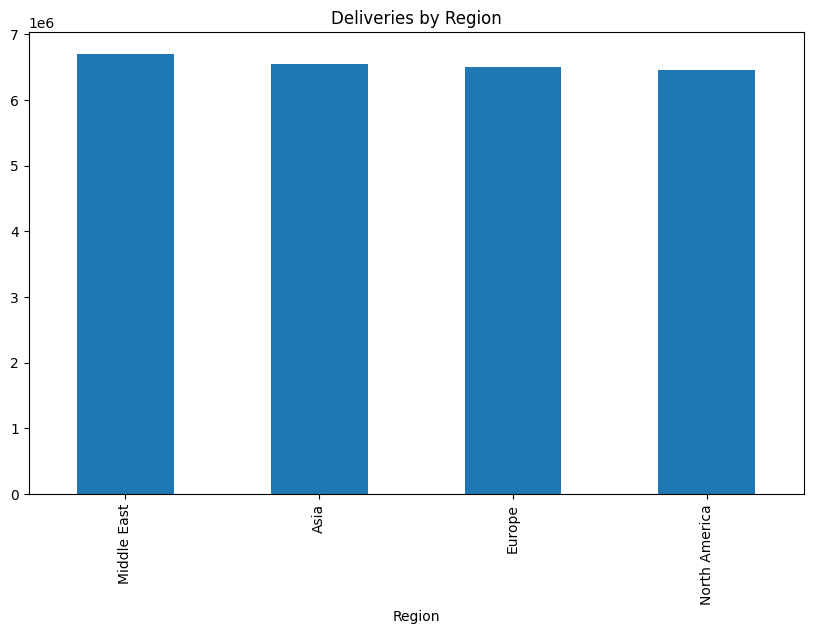

In [59]:
region_sales = (
    df.groupby("Region")
    ["Estimated_Deliveries"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

region_sales.plot(kind="bar")

plt.title("Deliveries by Region")

plt.show()

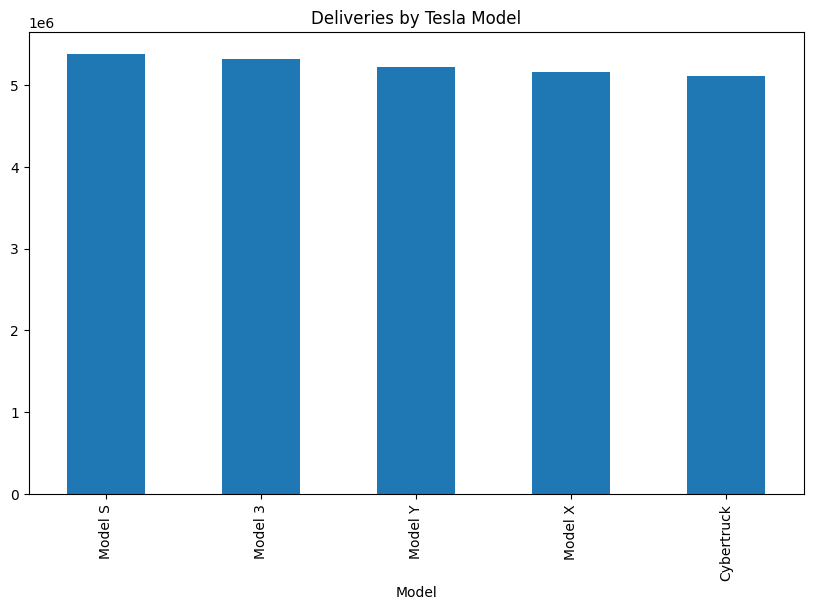

In [60]:
model_sales = (
    df.groupby("Model")
    ["Estimated_Deliveries"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

model_sales.plot(kind="bar")

plt.title("Deliveries by Tesla Model")

plt.show()

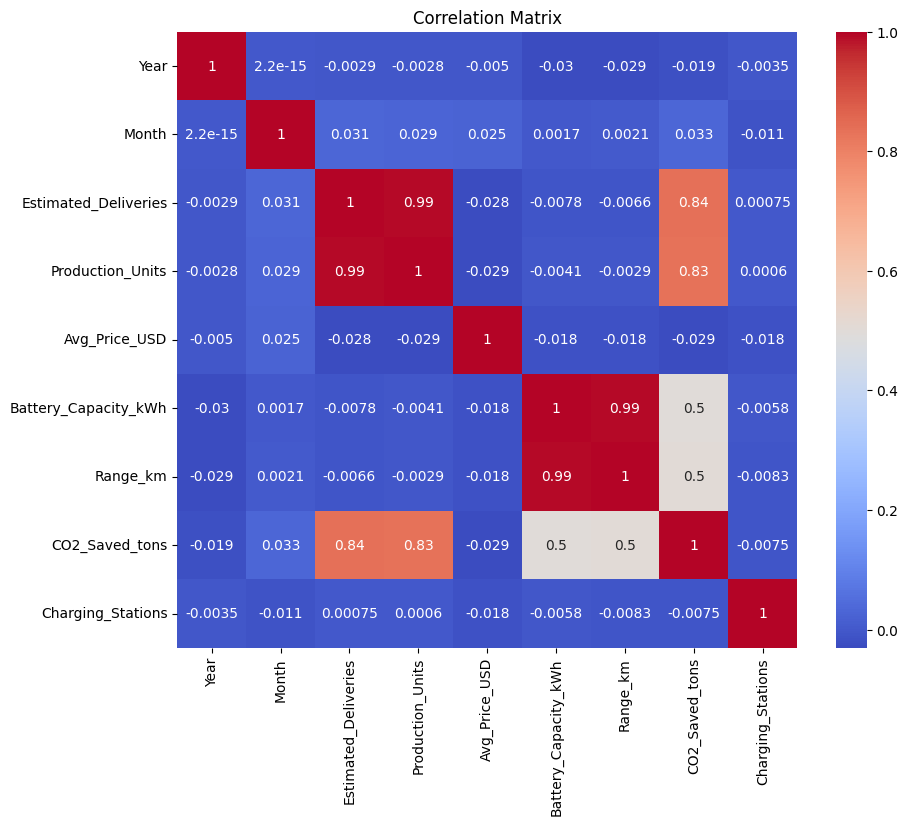

In [61]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.select_dtypes(include="number").corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

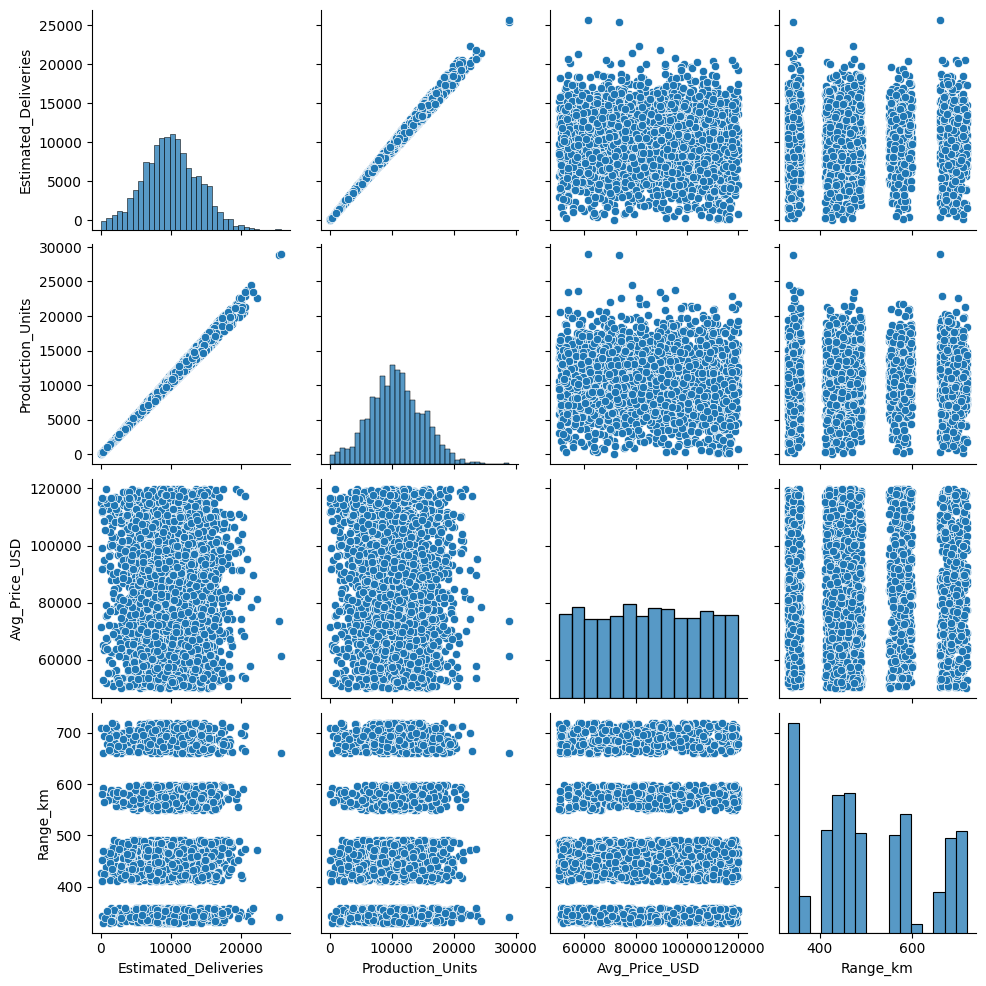

In [62]:
sns.pairplot(
    df[
        [
            "Estimated_Deliveries",
            "Production_Units",
            "Avg_Price_USD",
            "Range_km"
        ]
    ]
)

plt.show()

In [63]:
corr = df.select_dtypes(include='number').corr()

print(
    corr["Estimated_Deliveries"]
    .sort_values(ascending=False)
)

Estimated_Deliveries    1.000000
Production_Units        0.994234
CO2_Saved_tons          0.836814
Month                   0.030877
Charging_Stations       0.000753
Year                   -0.002863
Range_km               -0.006606
Battery_Capacity_kWh   -0.007765
Avg_Price_USD          -0.027546
Name: Estimated_Deliveries, dtype: float64


In [64]:
print(df["Region"].unique())

print(df["Model"].unique())

print(df["Source_Type"].unique())

['Europe' 'Asia' 'North America' 'Middle East']
['Model S' 'Model X' 'Model 3' 'Model Y' 'Cybertruck']
['Interpolated (Month)' 'Official (Quarter)' 'Estimated (Region)']


In [65]:
from sklearn.preprocessing import LabelEncoder

df_ml = df.copy()

le_region = LabelEncoder()
le_model = LabelEncoder()
le_source = LabelEncoder()

df_ml["Region"] = le_region.fit_transform(df_ml["Region"])
df_ml["Model"] = le_model.fit_transform(df_ml["Model"])
df_ml["Source_Type"] = le_source.fit_transform(df_ml["Source_Type"])

df_ml.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,1,2,17646,17922,92874.27,120,704,1863.42,1,12207
1,2015,2,0,3,3797,4164,62205.65,75,438,249.46,2,7640
2,2019,1,3,3,8411,9189,117887.32,82,480,605.59,1,14071
3,2021,2,3,1,6555,7311,89294.91,120,712,700.07,2,9333
4,2016,12,2,4,12374,13537,114846.78,120,661,1226.88,0,8722


In [66]:
df_ml["Production_Efficiency"] = (
    df_ml["Estimated_Deliveries"] /
    df_ml["Production_Units"]
)

df_ml["Price_per_KM"] = (
    df_ml["Avg_Price_USD"] /
    df_ml["Range_km"]
)

df_ml["Stations_per_Production"] = (
    df_ml["Charging_Stations"] /
    df_ml["Production_Units"]
)

In [67]:
df_ml.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Production_Efficiency,Price_per_KM,Stations_per_Production
0,2023,5,1,2,17646,17922,92874.27,120,704,1863.42,1,12207,0.984600,131.923679,0.681118
1,2015,2,0,3,3797,4164,62205.65,75,438,249.46,2,7640,0.911864,142.022032,1.834774
2,2019,1,3,3,8411,9189,117887.32,82,480,605.59,1,14071,0.915334,245.598583,1.531287
3,2021,2,3,1,6555,7311,89294.91,120,712,700.07,2,9333,0.896594,125.414199,1.276570
4,2016,12,2,4,12374,13537,114846.78,120,661,1226.88,0,8722,0.914087,173.747020,0.644308


In [68]:
X = df_ml.drop("Estimated_Deliveries", axis=1)

y = df_ml["Estimated_Deliveries"]

In [69]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(2112, 14)
(528, 14)


In [70]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [71]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("Linear Regression")

print("MAE:", mean_absolute_error(y_test, lr_pred))

print("RMSE:", mean_squared_error(
    y_test,
    lr_pred
)**0.5)

print("R2:", r2_score(y_test, lr_pred))

Linear Regression
MAE: 108.85094348357116
RMSE: 153.3348795770907
R2: 0.9984227069083972


In [72]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [73]:
print("Random Forest")

print("MAE:", mean_absolute_error(y_test, rf_pred))

print("RMSE:", mean_squared_error(
    y_test,
    rf_pred
)**0.5)

print("R2:", r2_score(y_test, rf_pred))

Random Forest
MAE: 67.0945265151515
RMSE: 109.51569875963267
R2: 0.9991953940399424


In [74]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators":[100,200],
    "max_depth":[5,10,None]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring="r2"
)

grid.fit(X_train,y_train)

print(grid.best_params_)

{'max_depth': None, 'n_estimators': 200}


In [75]:
best_model = grid.best_estimator_

import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

                    Feature  Importance
4          Production_Units    0.990234
11    Production_Efficiency    0.008658
8            CO2_Saved_tons    0.000238
13  Stations_per_Production    0.000196
12             Price_per_KM    0.000108
5             Avg_Price_USD    0.000103
1                     Month    0.000084
0                      Year    0.000084
10        Charging_Stations    0.000064
7                  Range_km    0.000064
3                     Model    0.000060
2                    Region    0.000053
9               Source_Type    0.000037
6      Battery_Capacity_kWh    0.000018


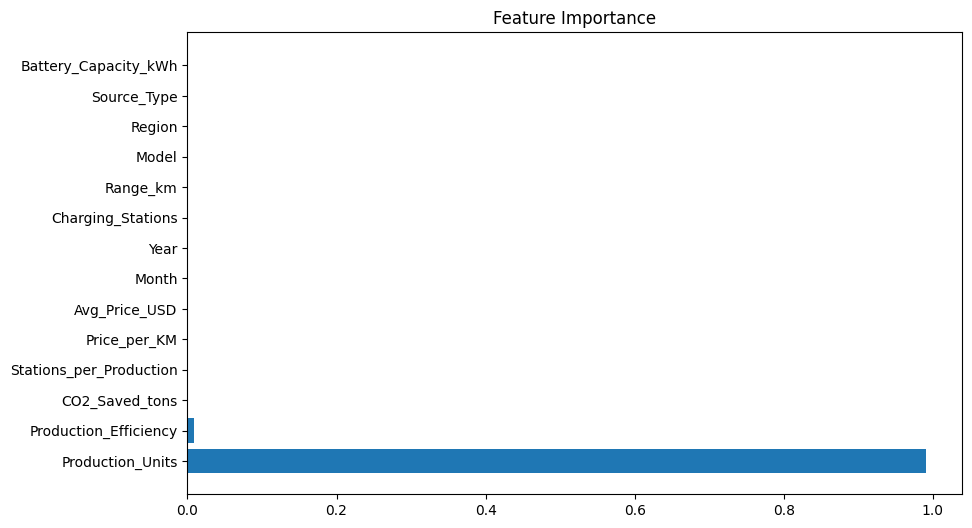

In [76]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Feature Importance")

plt.show()

In [77]:
df_ml["Price_per_KM"] = (
    df_ml["Avg_Price_USD"] /
    df_ml["Range_km"]
)

df_ml["Battery_per_KM"] = (
    df_ml["Battery_Capacity_kWh"] /
    df_ml["Range_km"]
)

df_ml["Stations_per_Production"] = (
    df_ml["Charging_Stations"] /
    df_ml["Production_Units"]
)

In [78]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("R2 Score:", r2_score(y_test, lr_pred))
print("MAE:", mean_absolute_error(y_test, lr_pred))
print("RMSE:", mean_squared_error(y_test, lr_pred)**0.5)

R2 Score: 0.9984227069083972
MAE: 108.85094348357116
RMSE: 153.3348795770907


In [79]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("R2 Score:", r2_score(y_test, rf_pred))
print("MAE:", mean_absolute_error(y_test, rf_pred))
print("RMSE:", mean_squared_error(y_test, rf_pred)**0.5)

R2 Score: 0.9991953940399424
MAE: 67.0945265151515
RMSE: 109.51569875963267


In [80]:
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators':[100,200],
    'max_depth':[5,10,None]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    params,
    cv=5,
    scoring='r2'
)

grid.fit(X_train, y_train)

print(grid.best_params_)
print(grid.best_score_)

{'max_depth': None, 'n_estimators': 200}
0.9980427221546753


In [81]:
df_ts = df.copy()

df_ts["Date"] = pd.to_datetime(
    df_ts["Year"].astype(str) + "-" +
    df_ts["Month"].astype(str)
)

monthly_sales = (
    df_ts.groupby("Date")
    ["Estimated_Deliveries"]
    .sum()
)

In [82]:
monthly_sales = monthly_sales.asfreq('MS')

In [83]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(
    monthly_sales,
    order=(1,1,1)
)

result = model.fit()

forecast = result.forecast(steps=12)

print(forecast)

2026-01-01    201130.711312
2026-02-01    199815.368230
2026-03-01    199605.917024
2026-04-01    199572.564655
2026-05-01    199567.253726
2026-06-01    199566.408030
2026-07-01    199566.273364
2026-08-01    199566.251920
2026-09-01    199566.248506
2026-10-01    199566.247962
2026-11-01    199566.247875
2026-12-01    199566.247862
Freq: MS, Name: predicted_mean, dtype: float64


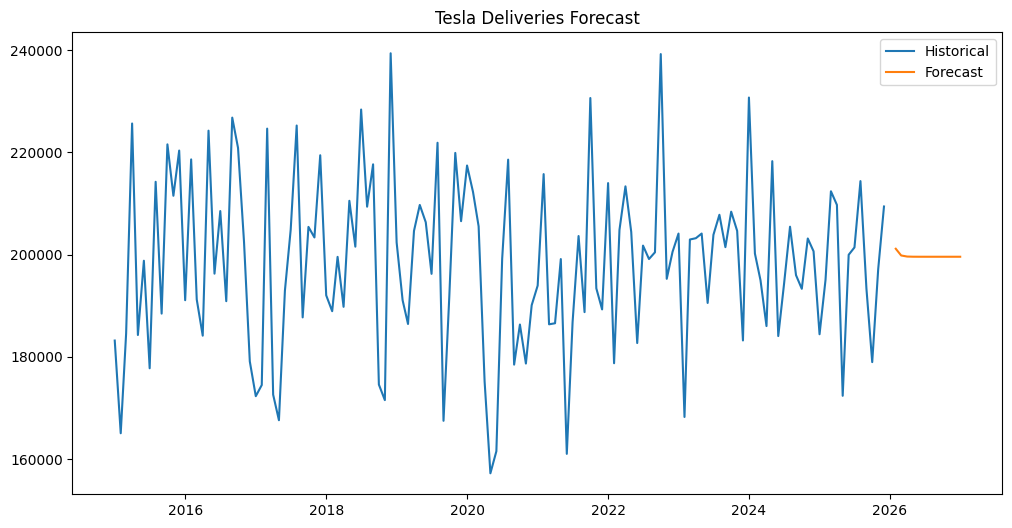

In [84]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    monthly_sales,
    label="Historical"
)

future_dates = pd.date_range(
    monthly_sales.index[-1],
    periods=13,
    freq="ME"
)[1:]

plt.plot(
    future_dates,
    forecast,
    label="Forecast"
)

plt.legend()
plt.title("Tesla Deliveries Forecast")

plt.show()

In [85]:
import pickle

pickle.dump(
    grid.best_estimator_,
    open("tesla_best_model.pkl","wb")
)

In [86]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

                    Feature  Importance
4          Production_Units    0.990301
11    Production_Efficiency    0.008644
13  Stations_per_Production    0.000245
8            CO2_Saved_tons    0.000194
5             Avg_Price_USD    0.000114
1                     Month    0.000082
0                      Year    0.000076
12             Price_per_KM    0.000076
10        Charging_Stations    0.000062
2                    Region    0.000052
7                  Range_km    0.000050
3                     Model    0.000045
9               Source_Type    0.000043
6      Battery_Capacity_kWh    0.000017


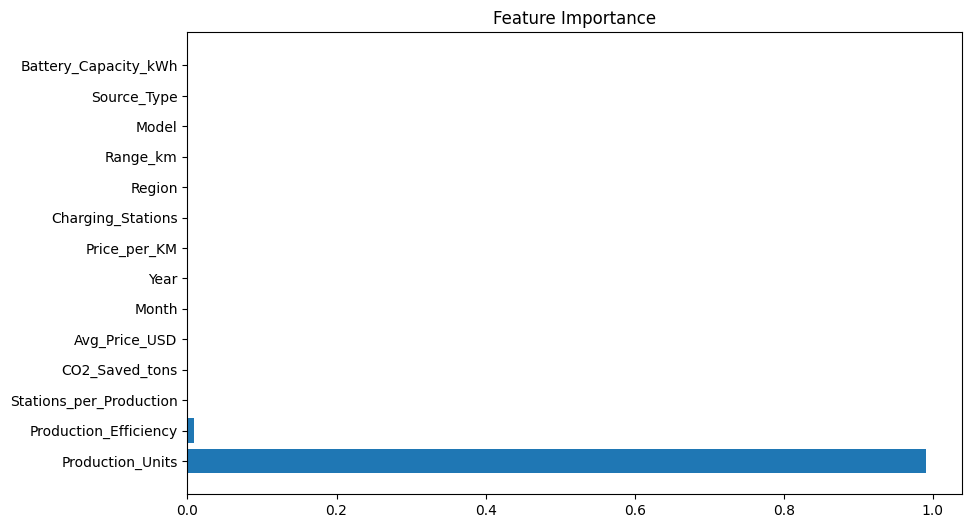

In [87]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Feature Importance")
plt.show()

In [88]:
df_ml = df_ml.drop("Production_Efficiency", axis=1)

In [89]:
X = df_ml.drop("Estimated_Deliveries", axis=1)
y = df_ml["Estimated_Deliveries"]

In [90]:
import pickle

with open("tesla_best_model.pkl", "wb") as f:
    pickle.dump(rf, f)

In [91]:
import os
print(os.listdir())

['tesla_best_model.pkl', '.virtual_documents']
